# Parallel Transport and Holonomy

Parallel transport is the operation that lets you compare tangent vectors at different points of a manifold — a prerequisite for message passing in a GNN or convolution on a curved domain. This notebook shows transport along a path, then **holonomy**: a vector carried around a closed loop returns rotated. That rotation is why ambient Euclidean arithmetic is not valid on curved data. Rotate the 3-D scenes to inspect the transported frames.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

`Manifold.parallel_transport(x, y, v)` carries a tangent vector $v \in T_xM$ along the geodesic to $y$,
giving a vector in $T_yM$. For the sphere this is the exact Levi-Civita transport; for a general Finsler
metric the analogue is the Berwald connection (`ham.geometry.BerwaldConnection`), derived from the spray.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Sphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
sphere = Sphere(radius=1.0)

## 2. Transporting a vector along a path

We transport a vector along a geodesic, one segment at a time. It keeps a constant angle to the path
tangent — the defining property of parallel transport. The cones mark the transported vector at samples
along the curve.

In [2]:
def geodesic(p, q, n=60):
    v = sphere.log_map(p, q)
    ts = jnp.linspace(0, 1, n)
    return jax.vmap(lambda t: sphere.exp_map(p, t * v))(ts)


def transport_along(path, v0):
    def step(v, idx):
        v_new = sphere.parallel_transport(path[idx], path[idx + 1], v)
        return v_new, v_new
    _, vs = jax.lax.scan(step, v0, jnp.arange(path.shape[0] - 1))
    return jnp.concatenate([v0[None], vs], axis=0)


start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([0.0, 0.6, 0.8]); end = end / jnp.linalg.norm(end)
path = geodesic(start, end, n=60)
v0 = sphere.to_tangent(start, jnp.array([0.0, 1.0, 0.0])); v0 = v0 / jnp.linalg.norm(v0)
vecs = np.array(transport_along(path, v0))
P = np.array(path)
s = slice(0, len(P), 5)

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(P, color=PALETTE["ink"], name="geodesic", width=5, show_start=False))
fig.add_trace(plotly_cones(P[s], vecs[s], name="transported vector", sizeref=0.45,
                           color=PALETTE["primary"]))
plotly_layout(fig, "Parallel transport along a geodesic")
fig.show()

## 3. Holonomy on a closed loop

We transport a vector around a spherical triangle: equator point $A$ → equator point $B$ → north pole
$N$ → back to $A$, each leg a geodesic. On a flat space the vector would return unchanged; on the sphere
it returns rotated by the enclosed area (Gauss–Bonnet). For this octant the area is $\pi/2$, so we expect
a $90^\circ$ rotation. The blue and orange cones at $A$ are the initial and returned vectors.

In [3]:
A = jnp.array([1.0, 0.0, 0.0])
B = jnp.array([0.0, 1.0, 0.0])
N = jnp.array([0.0, 0.0, 1.0])
loop = jnp.concatenate([geodesic(A, B, 40), geodesic(B, N, 40), geodesic(N, A, 40)], axis=0)

v_init = sphere.to_tangent(A, jnp.array([0.0, 1.0, 0.0])); v_init = v_init / jnp.linalg.norm(v_init)
loop_vecs = np.array(transport_along(loop, v_init))
v_final = loop_vecs[-1]
cos_ang = float(np.dot(v_init, v_final) / (np.linalg.norm(v_init) * np.linalg.norm(v_final)))
holonomy_deg = np.degrees(np.arccos(np.clip(cos_ang, -1, 1)))
print(f"initial vector : {np.round(np.array(v_init), 3)}")
print(f"returned vector: {np.round(v_final, 3)}")
print(f"holonomy angle : {holonomy_deg:.2f} deg   (enclosed area = pi/2 -> 90)")

L = np.array(loop)
s = slice(0, len(L), 7)
fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_path(L, color=PALETTE["ink"], name="closed loop", width=5, show_start=False))
fig.add_trace(plotly_cones(L[s], loop_vecs[s], name="transported", sizeref=0.4, color=PALETTE["teal"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_init[None], name="initial", sizeref=0.2,
                           color=PALETTE["primary"]))
fig.add_trace(plotly_cones(np.array(A)[None], v_final[None], name="returned", sizeref=0.2,
                           color=PALETTE["accent"]))
plotly_layout(fig, f"Holonomy: the vector returns rotated by {holonomy_deg:.0f} degrees")
fig.show()

initial vector : [0. 1. 0.]
returned vector: [ 0. -0.  1.]
holonomy angle : 90.00 deg   (enclosed area = pi/2 -> 90)


## 4. Holonomy is proportional to enclosed area

Gauss–Bonnet predicts the holonomy of a geodesic loop on the unit sphere equals the solid angle it
encloses. We confirm it by transporting around latitude circles of growing size: a small loop gives
little holonomy, a large loop gives a large rotation.

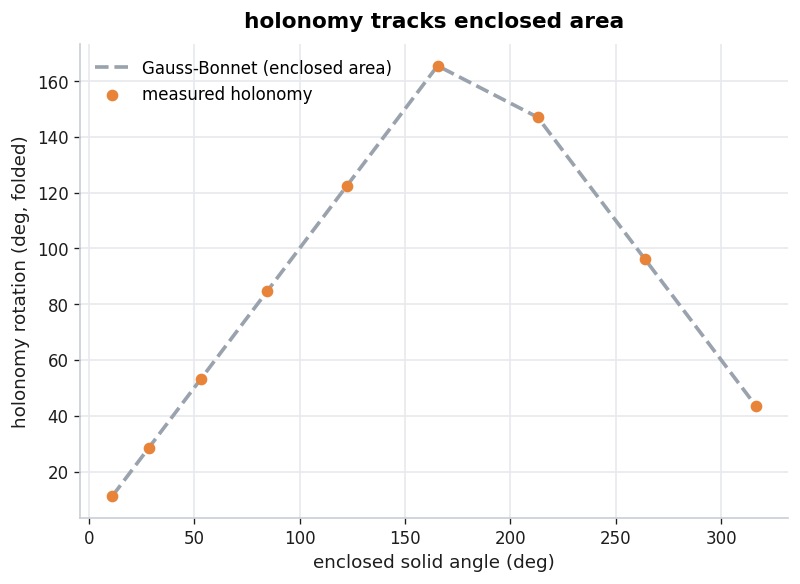

In [4]:
def cap_loop(theta_cap, n=120):
    phi = jnp.linspace(0, 2 * jnp.pi, n)
    r = jnp.sin(theta_cap)
    return jnp.stack([r * jnp.cos(phi), r * jnp.sin(phi),
                      jnp.cos(theta_cap) * jnp.ones_like(phi)], axis=1)


caps = np.linspace(0.25, 1.45, 9)
measured, enclosed = [], []
for tc in caps:
    lp = cap_loop(tc)
    v0c = sphere.to_tangent(lp[0], jnp.array([0.0, 0.0, 1.0])); v0c = v0c / jnp.linalg.norm(v0c)
    vend = np.array(transport_along(lp, v0c))[-1]
    ca = float(np.dot(v0c, vend) / (np.linalg.norm(v0c) * np.linalg.norm(vend)))
    measured.append(np.degrees(np.arccos(np.clip(ca, -1, 1))))
    enclosed.append(np.degrees(2 * np.pi * (1 - np.cos(tc))))

measured = np.minimum(np.array(measured), 360 - np.array(measured))
predicted = np.minimum(np.array(enclosed), 360 - np.array(enclosed))

fig, ax = plt.subplots(figsize=(6.8, 5))
ax.plot(enclosed, predicted, "--", color=PALETTE["muted"], label="Gauss-Bonnet (enclosed area)")
ax.scatter(enclosed, measured, color=PALETTE["accent"], zorder=5, label="measured holonomy")
ax.set_xlabel("enclosed solid angle (deg)"); ax.set_ylabel("holonomy rotation (deg, folded)")
ax.set_title("holonomy tracks enclosed area"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Non-Riemannian holonomy: a diffeomorphism, not a rotation

Everything above is Riemannian, and there transport is a *linear isometry*: going round a loop
rotates the whole tangent plane rigidly, by one angle, the same for every vector.

Finsler geometry keeps less. The canonical parallel translation is the **horizontal** one, carried by
the nonlinear connection $N^i_j=\partial G^i/\partial y^j$ that the spray induces. It is only
positively 1-homogeneous, not linear, and instead of preserving the fundamental tensor it preserves
the norm function $F$. That is still enough to send the indicatrix
$\mathcal I_x=\{y : F(x,y)=1\}$ to the indicatrix — so holonomy acts on a sphere by
*diffeomorphisms*, and its natural home is $\mathrm{Diff}(\mathcal I)$ rather than $O(n)$.

We compare two metrics on the unit disk along the same loop:

| | | |
| :-- | :-- | :-- |
| **Poincaré** | $F=2\lVert y\rVert/(1-\lVert x\rVert^2)$ | Riemannian, curvature $-1$ |
| **Funk** | $F=\bigl(\sqrt{\lVert y\rVert^2-(\lVert x\rVert^2\lVert y\rVert^2-\langle x,y\rangle^2)}+\langle x,y\rangle\bigr)/(1-\lVert x\rVert^2)$ | Randers, projectively flat, flag curvature $-1/4$ |

If holonomy were always a rotation, the turning angle would not depend on which direction we started
from. The Funk metric is where that fails.

In [5]:
from ham.geometry import EuclideanSpace
from ham.geometry.metric import FinslerMetric
from ham.geometry.transport import BerwaldConnection

disk = EuclideanSpace(dim=2)


class Poincare(FinslerMetric):
    """Poincare disk. Riemannian, constant curvature -1. The control."""

    def metric_fn(self, x, y):
        return 2.0 * jnp.sqrt(jnp.maximum(jnp.dot(y, y), 1e-12)) / (1.0 - jnp.dot(x, x))


class Funk(FinslerMetric):
    """Funk metric. Randers, projectively flat, flag curvature -1/4, non-reversible."""

    def metric_fn(self, x, y):
        x2, y2, xy = jnp.dot(x, x), jnp.dot(y, y), jnp.dot(x, y)
        disc = jnp.maximum(y2 - (x2 * y2 - xy**2), 1e-12)
        return (jnp.sqrt(disc) + xy) / (1.0 - x2)


def disk_loop(steps, centre=jnp.array([0.10, 0.05]), radius=0.35):
    """A closed circle in the disk, parametrised over [0, 1]."""
    ang = 2 * jnp.pi * jnp.linspace(0.0, 1.0, steps + 1)
    xs = centre + radius * jnp.stack([jnp.cos(ang), jnp.sin(ang)], axis=1)
    vs = 2 * jnp.pi * radius * jnp.stack([-jnp.sin(ang), jnp.cos(ang)], axis=1)
    return xs, vs


def indicatrix(metric, x, n=400):
    """Unit-cost vectors at x. F is 1-homogeneous, so scale each direction by 1/F."""
    theta = jnp.linspace(0, 2 * jnp.pi, n, endpoint=False)
    u = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=1)
    return u / jax.vmap(metric.metric_fn, in_axes=(None, 0))(x, u)[:, None]


def holonomy(metric, steps, n_dirs=48):
    """Transport every indicatrix direction around the loop; report where each lands."""
    xs, vs = disk_loop(steps)
    conn = BerwaldConnection(metric)
    Y = indicatrix(metric, xs[0], n_dirs)
    P = jax.vmap(lambda y: conn.parallel_transport(xs, vs, y)[-1])(Y)
    F_out = jax.vmap(metric.metric_fn, in_axes=(None, 0))(xs[0], P)
    turn = jnp.arctan2(P[:, 1], P[:, 0]) - jnp.arctan2(Y[:, 1], Y[:, 0])
    turn = jnp.mod(turn + jnp.pi, 2 * jnp.pi) - jnp.pi
    return Y, P, np.asarray(F_out), np.degrees(np.asarray(turn))


STEPS = 2000
Y_p, P_p, F_p, turn_p = holonomy(Poincare(disk), STEPS)
Y_f, P_f, F_f, turn_f = holonomy(Funk(disk), STEPS)
_, _, _, turn_f2 = holonomy(Funk(disk), 2 * STEPS)  # refinement check

for name, F_out, turn in (("Poincare", F_p, turn_p), ("Funk", F_f, turn_f)):
    print(f"{name:9s}  F on the indicatrix stays in [{F_out.min():.5f}, {F_out.max():.5f}]"
          f"   turning angle spread = {turn.max() - turn.min():8.4f} deg")
print(f"\nFunk spread at {STEPS} steps: {turn_f.max() - turn_f.min():.4f} deg")
print(f"Funk spread at {2 * STEPS} steps: {turn_f2.max() - turn_f2.min():.4f} deg"
      "   (converged, so it is not integration error)")

Poincare   F on the indicatrix stays in [1.00085, 1.00085]   turning angle spread =   0.0001 deg
Funk       F on the indicatrix stays in [0.99885, 0.99936]   turning angle spread =   5.5894 deg

Funk spread at 2000 steps: 5.5894 deg
Funk spread at 4000 steps: 5.5890 deg   (converged, so it is not integration error)


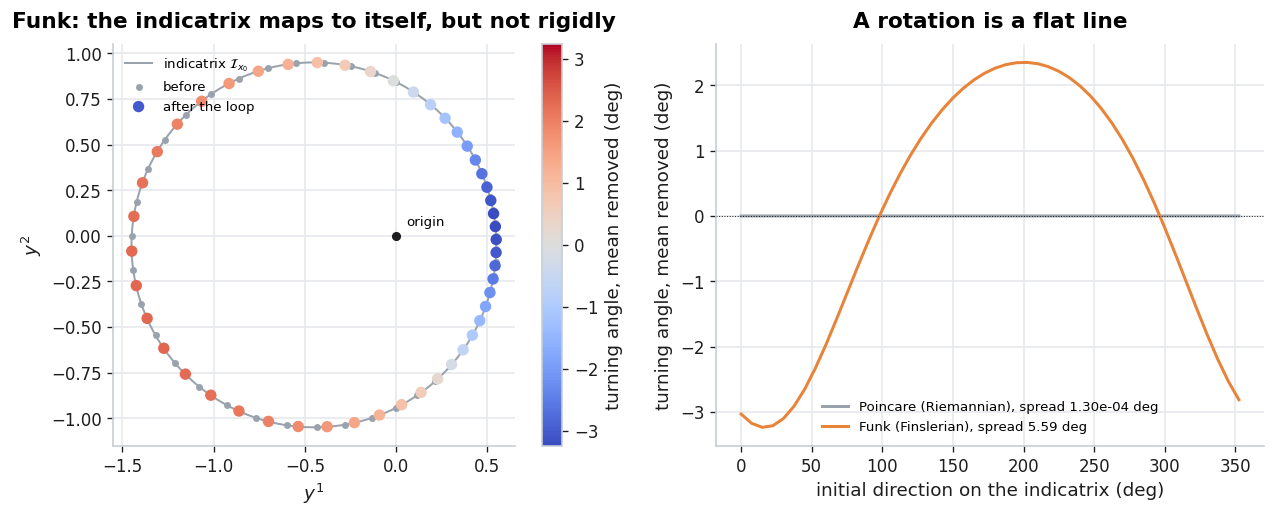

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

# --- left: the indicatrix, and where transport sends it ---
x0 = disk_loop(STEPS)[0][0]
curve = np.asarray(indicatrix(Funk(disk), x0, 400))
ax1.plot(*np.vstack([curve, curve[:1]]).T, color=PALETTE["muted"], lw=1.2,
         label=r"indicatrix $\mathcal{I}_{x_0}$")
dev = turn_f - turn_f.mean()
lim = np.abs(dev).max()
ax1.scatter(*np.asarray(Y_f).T, s=10, color=PALETTE["muted"], zorder=4, label="before")
sc = ax1.scatter(*np.asarray(P_f).T, c=dev, cmap="coolwarm", vmin=-lim, vmax=lim,
                 s=34, zorder=5, label="after the loop")
ax1.scatter([0], [0], s=20, color=PALETTE["ink"], zorder=6)
ax1.annotate("origin", xy=(0, 0), xytext=(6, 6), textcoords="offset points", fontsize=8)
ax1.set_aspect("equal")
ax1.set_title("Funk: the indicatrix maps to itself, but not rigidly")
ax1.set_xlabel("$y^1$"); ax1.set_ylabel("$y^2$"); ax1.legend(fontsize=8, loc="upper left")
fig.colorbar(sc, ax=ax1, label="turning angle, mean removed (deg)")

# --- right: is the turning angle the same for every direction? ---
theta = np.degrees(np.linspace(0, 2 * np.pi, len(turn_f), endpoint=False))
ax2.plot(theta, turn_p - turn_p.mean(), color=PALETTE["muted"], lw=1.8,
         label=f"Poincare (Riemannian), spread {turn_p.max() - turn_p.min():.2e} deg")
ax2.plot(theta, turn_f - turn_f.mean(), color=PALETTE["accent"], lw=1.8,
         label=f"Funk (Finslerian), spread {turn_f.max() - turn_f.min():.2f} deg")
ax2.axhline(0.0, color=PALETTE["ink"], lw=0.6, ls=":")
ax2.set_xlabel("initial direction on the indicatrix (deg)")
ax2.set_ylabel("turning angle, mean removed (deg)")
ax2.set_title("A rotation is a flat line")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

A rotation would be a flat line on the right-hand plot, and for the Poincaré disk it is: every
direction comes back turned by the same angle, to within integration error. The Funk metric does not
do that. Different directions on the indicatrix come back turned by different amounts, and the spread
is unchanged when the step count is doubled, so it is a property of the geometry rather than of the
integrator.

The map is still a bijection of $\mathcal{I}_{x_0}$ — transport preserves $F$, which is what keeps
every image on the curve — but it is not the restriction of any linear map. That is the whole
difference: in the Riemannian case holonomy lands in $O(n)$, a finite-dimensional Lie group whose
possibilities Berger classified; here it lands in $\mathrm{Diff}(\mathcal{I})$, and for almost all
Finsler metrics the group it generates is infinite dimensional (Hubicska–Matveev–Muzsnay).

## 6. Why this matters for ML

* To compare or aggregate tangent features at different manifold points (attention scores, GNN messages,
  flow on a sphere), transport them to a common tangent space first; ambient subtraction is not
  meaningful.
* Holonomy is the obstruction that makes a curved space curved: there is no global frame in which
  transport is trivial. Methods that ignore it accumulate error proportional to the curvature.
* HAM provides both the Riemannian transport used here (`Manifold.parallel_transport`) and the
  horizontal Finslerian translation (`BerwaldConnection`) for asymmetric or learned metrics, from the
  same scalar $F$. The Riemannian one is a rotation; the Finslerian one need not be, as section 5
  shows.